In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from utils import show_prompt
from deep_research_from_scratch.prompts import research_agent_prompt
show_prompt(research_agent_prompt, "Research Agent Instructions")

╭────────────────────────────────────────── Research Agent Instructions ──────────────────────────────────────────╮
│                                                                                                                 │
│  You are a research assistant conducting research on the user's input topic. For context, today's date is       │
│  {date}.                                                                                                        │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  Your job is to use tools to gather information about the user's input topic.                                   │
│  You can use any of the tools provided to you to find resources that can help answer the research question.     │
│  You can call these tools in series or in parallel, your research is conducted in a tool-calling loop.          │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Tools>                                                                                              │
│  You have access to two main tools:                                                                             │
│  1. **tavily_search**: For conducting web searches to gather information                                        │
│  2. **think_tool**: For reflection and strategic planning during research                                       │
│                                                                                                                 │
│  **CRITICAL: Use think_tool after each search to reflect on results and plan next steps**                       │
│  </Available Tools>                                                                                             │
│                                                                                                                 │
│  <Instructions>                                                                                                 │
│  Think like a human researcher with limited time. Follow these steps:                                           │
│                                                                                                                 │
│  1. **Read the question carefully** - What specific information does the user need?                             │
│  2. **Start with broader searches** - Use broad, comprehensive queries first                                    │
│  3. **After each search, pause and assess** - Do I have enough to answer? What's still missing?                 │
│  4. **Execute narrower searches as you gather information** - Fill in the gaps                                  │
│  5. **Stop when you can answer confidently** - Don't keep searching for perfection                              │
│  </Instructions>                                                                                                │
│                                                                                                                 │
│  <Hard Limits>                                                                                                  │
│  **Tool Call Budgets** (Prevent excessive searching):                                                           │
│  - **Simple queries**: Use 2-3 search tool calls maximum                                                        │
│  - **Complex queries**: Use up to 5 search tool calls maximum                                                   │
│  - **Always stop**: After 5 search tool calls if you cannot find the right sources                              │
│                                                       

In [3]:
import operator
from typing_extensions import TypedDict, Annotated, List, Sequence
from pydantic import BaseModel, Field
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

# ===== STATE DEFINITIONS =====

class ResearcherState(TypedDict):
    """
    State for the research agent containing message history and research metadata.
    
    This state tracks the researcher's conversation, iteration count for limiting
    tool calls, the research topic being investigated, compressed findings,
    and raw research notes for detailed analysis.
    """
    researcher_messages: Annotated[Sequence[BaseMessage], add_messages]
    tool_call_iterations: int
    research_topic: str
    compressed_research: str
    raw_notes: Annotated[List[str], operator.add]

class ResearcherOutputState(TypedDict):
    """
    Output state for the research agent containing final research results.
    
    This represents the final output of the research process with compressed
    research findings and all raw notes from the research process.
    """
    compressed_research: str
    raw_notes: Annotated[List[str], operator.add]
    researcher_messages: Annotated[Sequence[BaseMessage], add_messages]

# ===== STRUCTURED OUTPUT SCHEMAS =====

class ClarifyWithUser(BaseModel):
    """Schema for user clarification decisions during scoping phase."""
    need_clarification: bool = Field(
        description="Whether the user needs to be asked a clarifying question.",
    )
    question: str = Field(
        description="A question to ask the user to clarify the report scope",
    )
    verification: str = Field(
        description="Verify message that we will start research after the user has provided the necessary information.",
    )

class ResearchQuestion(BaseModel):
    """Schema for research brief generation."""
    research_brief: str = Field(
        description="A research question that will be used to guide the research.",
    )

class Summary(BaseModel):
    """Schema for webpage content summarization."""
    summary: str = Field(description="Concise summary of the webpage content")
    key_excerpts: str = Field(description="Important quotes and excerpts from the content")

In [4]:
from pathlib import Path
from datetime import datetime
from typing_extensions import Annotated, List, Literal

from langchain.chat_models import init_chat_model 
from langchain_core.messages import HumanMessage
from langchain_core.runnables import RunnableConfig
from langchain_core.tools import tool, InjectedToolArg
from tavily import TavilyClient

from deep_research_from_scratch.state_research import Summary
from deep_research_from_scratch.prompts import summarize_webpage_prompt

# ===== UTILITY FUNCTIONS =====

def get_today_str() -> str:
    """Get current date in a human-readable format."""
    return datetime.now().strftime("%a %b %-d, %Y")

def get_current_dir() -> Path:
    """Get the current directory of the module.

    This function is compatible with Jupyter notebooks and regular Python scripts.

    Returns:
        Path object representing the current directory
    """
    try:
        return Path(__file__).resolve().parent
    except NameError:  # __file__ is not defined
        return Path.cwd()

# ===== CONFIGURATION =====

summarization_model = init_chat_model(model="openai:gpt-4.1-mini")
tavily_client = TavilyClient()

# ===== SEARCH FUNCTIONS =====

def tavily_search_multiple(
    search_queries: List[str], 
    max_results: int = 3, 
    topic: Literal["general", "news", "finance"] = "general", 
    include_raw_content: bool = True, 
) -> List[dict]:
    """Perform search using Tavily API for multiple queries.

    Args:
        search_queries: List of search queries to execute
        max_results: Maximum number of results per query
        topic: Topic filter for search results
        include_raw_content: Whether to include raw webpage content

    Returns:
        List of search result dictionaries
    """
    
    # Execute searches sequentially. Note: yon can use AsyncTavilyClient to parallelize this step.
    search_docs = []
    for query in search_queries:
        result = tavily_client.search(
            query,
            max_results=max_results,
            include_raw_content=include_raw_content,
            topic=topic
        )
        search_docs.append(result)

    return search_docs

def summarize_webpage_content(webpage_content: str) -> str:
    """Summarize webpage content using the configured summarization model.
    
    Args:
        webpage_content: Raw webpage content to summarize
        
    Returns:
        Formatted summary with key excerpts
    """
    try:
        # Set up structured output model for summarization
        structured_model = summarization_model.with_structured_output(Summary)
        
        # Generate summary
        summary = structured_model.invoke([
            HumanMessage(content=summarize_webpage_prompt.format(
                webpage_content=webpage_content, 
                date=get_today_str()
            ))
        ])
        
        # Format summary with clear structure
        formatted_summary = (
            f"<summary>\n{summary.summary}\n</summary>\n\n"
            f"<key_excerpts>\n{summary.key_excerpts}\n</key_excerpts>"
        )
        
        return formatted_summary
        
    except Exception as e:
        print(f"Failed to summarize webpage: {str(e)}")
        return webpage_content[:1000] + "..." if len(webpage_content) > 1000 else webpage_content

def deduplicate_search_results(search_results: List[dict]) -> dict:
    """Deduplicate search results by URL to avoid processing duplicate content.
    
    Args:
        search_results: List of search result dictionaries
        
    Returns:
        Dictionary mapping URLs to unique results
    """
    unique_results = {}
    
    for response in search_results:
        for result in response['results']:
            url = result['url']
            if url not in unique_results:
                unique_results[url] = result
    
    return unique_results

def process_search_results(unique_results: dict) -> dict:
    """Process search results by summarizing content where available.
    
    Args:
        unique_results: Dictionary of unique search results
        
    Returns:
        Dictionary of processed results with summaries
    """
    summarized_results = {}
    
    for url, result in unique_results.items():
        # Use existing content if no raw content for summarization
        if not result.get("raw_content"):
            content = result['content']
        else:
            # Summarize raw content for better processing
            content = summarize_webpage_content(result['raw_content'])
        
        summarized_results[url] = {
            'title': result['title'],
            'content': content
        }
    
    return summarized_results

def format_search_output(summarized_results: dict) -> str:
    """Format search results into a well-structured string output.
    
    Args:
        summarized_results: Dictionary of processed search results
        
    Returns:
        Formatted string of search results with clear source separation
    """
    if not summarized_results:
        return "No valid search results found. Please try different search queries or use a different search API."
    
    formatted_output = "Search results: \n\n"
    
    for i, (url, result) in enumerate(summarized_results.items(), 1):
        formatted_output += f"\n\n--- SOURCE {i}: {result['title']} ---\n"
        formatted_output += f"URL: {url}\n\n"
        formatted_output += f"SUMMARY:\n{result['content']}\n\n"
        formatted_output += "-" * 80 + "\n"
    
    return formatted_output

# ===== RESEARCH TOOLS =====

@tool(parse_docstring=True)
def tavily_search(
    query: str,
    max_results: Annotated[int, InjectedToolArg] = 3,
    topic: Annotated[Literal["general", "news", "finance"], InjectedToolArg] = "general",
) -> str:
    """Fetch results from Tavily search API with content summarization.

    Args:
        query: A single search query to execute
        max_results: Maximum number of results to return
        topic: Topic to filter results by ('general', 'news', 'finance')

    Returns:
        Formatted string of search results with summaries
    """
    # Execute search for single query
    search_results = tavily_search_multiple(
        [query],  # Convert single query to list for the internal function
        max_results=max_results,
        topic=topic,
        include_raw_content=True,
    )

    # Deduplicate results by URL to avoid processing duplicate content
    unique_results = deduplicate_search_results(search_results)

    # Process results with summarization
    summarized_results = process_search_results(unique_results)

    # Format output for consumption
    return format_search_output(summarized_results)

@tool(parse_docstring=True)
def think_tool(reflection: str) -> str:
    """Tool for strategic reflection on research progress and decision-making.
    
    Use this tool after each search to analyze results and plan next steps systematically.
    This creates a deliberate pause in the research workflow for quality decision-making.
    
    When to use:
    - After receiving search results: What key information did I find?
    - Before deciding next steps: Do I have enough to answer comprehensively?
    - When assessing research gaps: What specific information am I still missing?
    - Before concluding research: Can I provide a complete answer now?
    
    Reflection should address:
    1. Analysis of current findings - What concrete information have I gathered?
    2. Gap assessment - What crucial information is still missing?
    3. Quality evaluation - Do I have sufficient evidence/examples for a good answer?
    4. Strategic decision - Should I continue searching or provide my answer?
    
    Args:
        reflection: Your detailed reflection on research progress, findings, gaps, and next steps
        
    Returns:
        Confirmation that reflection was recorded for decision-making
    """
    return f"Reflection recorded: {reflection}"

In [5]:
from pydantic import BaseModel, Field
from typing_extensions import Literal

from langgraph.graph import StateGraph, START, END
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage, filter_messages
from langchain.chat_models import init_chat_model

from deep_research_from_scratch.state_research import ResearcherState, ResearcherOutputState
from deep_research_from_scratch.utils import tavily_search, get_today_str, think_tool
from deep_research_from_scratch.prompts import research_agent_prompt, compress_research_system_prompt, compress_research_human_message

# ===== CONFIGURATION =====

# Set up tools and model binding
tools = [tavily_search, think_tool]
tools_by_name = {tool.name: tool for tool in tools}

# Initialize models
model = init_chat_model(model="openai:gpt-5-nano")
model_with_tools = model.bind_tools(tools)
summarization_model = init_chat_model(model="openai:gpt-5-nano")
compress_model = init_chat_model(model="openai:gpt-5-nano", max_tokens=32000) # model="anthropic:claude-sonnet-4-20250514", max_tokens=64000

# ===== AGENT NODES =====

def llm_call(state: ResearcherState):
    """Analyze current state and decide on next actions.
    
    The model analyzes the current conversation state and decides whether to:
    1. Call search tools to gather more information
    2. Provide a final answer based on gathered information
    
    Returns updated state with the model's response.
    """
    return {
        "researcher_messages": [
            model_with_tools.invoke(
                [SystemMessage(content=research_agent_prompt)] + state["researcher_messages"]
            )
        ]
    }

def tool_node(state: ResearcherState):
    """Execute all tool calls from the previous LLM response.
    
    Executes all tool calls from the previous LLM responses.
    Returns updated state with tool execution results.
    """
    tool_calls = state["researcher_messages"][-1].tool_calls
    # researcher_messages is a list of message objects (AIMessage/ToolMessage/etc.). 
    # Each message can include a tool_calls attribute (a list of dicts describing tool requests).
 
    # Execute all tool calls
    observations = []
    for tool_call in tool_calls:
        tool = tools_by_name[tool_call["name"]]#tools_by_name is created above
        observations.append(tool.invoke(tool_call["args"]))

    # {
    # "name": "tavily_search",
    # "id": "call_001",
    # "type": "tool_call",
    # "args": { "query": "best coffee shops san francisco", "max_results": 3 }
    # }
    
    # Create tool message outputs
    tool_outputs = [
        ToolMessage(
            content=observation,
            name=tool_call["name"],
            tool_call_id=tool_call["id"]
        ) for observation, tool_call in zip(observations, tool_calls)
    ]
    
    return {"researcher_messages": tool_outputs}

def compress_research(state: ResearcherState) -> dict:
    """Compress research findings into a concise summary.
    
    Takes all the research messages and tool outputs and creates
    a compressed summary suitable for the supervisor's decision-making.
    """
    
    system_message = compress_research_system_prompt.format(date=get_today_str())
    messages = [SystemMessage(content=system_message)] + state.get("researcher_messages", []) + [HumanMessage(content=compress_research_human_message)]
    response = compress_model.invoke(messages)
    
    # Extract raw notes from tool and AI messages
    raw_notes = [
        str(m.content) for m in filter_messages(
            state["researcher_messages"], 
            include_types=["tool", "ai"]
        )
        # It filters a conversation history by message class or role so you can control what context is sent to the LLM.
    ]
    
    return {
        "compressed_research": str(response.content),
        "raw_notes": ["\n".join(raw_notes)]
    }

# ===== ROUTING LOGIC =====

def should_continue(state: ResearcherState) -> Literal["tool_node", "compress_research"]:
    """Determine whether to continue research or provide final answer.
    
    Determines whether the agent should continue the research loop or provide
    a final answer based on whether the LLM made tool calls.
    
    Returns:
        "tool_node": Continue to tool execution
        "compress_research": Stop and compress research
    """
    messages = state["researcher_messages"]
    last_message = messages[-1]
    
    # If the LLM makes a tool call, continue to tool execution
    if last_message.tool_calls:
        return "tool_node"
    # Otherwise, we have a final answer
    return "compress_research"

# ===== GRAPH CONSTRUCTION =====

# Build the agent workflow
agent_builder = StateGraph(ResearcherState, output_schema=ResearcherOutputState)

# Add nodes to the graph
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)
agent_builder.add_node("compress_research", compress_research)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        "tool_node": "tool_node", # Continue research loop
        "compress_research": "compress_research", # Provide final answer
    },
)
agent_builder.add_edge("tool_node", "llm_call") # Loop back for more research
agent_builder.add_edge("compress_research", END)

# Compile the agent
researcher_agent = agent_builder.compile()

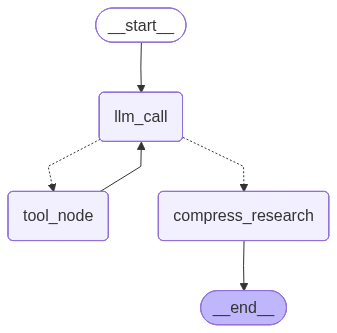

In [6]:
from IPython.display import Image, display
from deep_research_from_scratch.research_agent import researcher_agent

# Show the agent
display(Image(researcher_agent.get_graph(xray=True).draw_mermaid_png()))

In [7]:
# Run the agent
from utils import format_messages
from langchain_core.messages import HumanMessage

# Example brief
research_brief = """I want to identify and evaluate the coffee shops in San Francisco that are considered the best based specifically  
on coffee quality. My research should focus on analyzing and comparing coffee shops within the San Francisco area, 
using coffee quality as the primary criterion. I am open regarding methods of assessing coffee quality (e.g.,      
expert reviews, customer ratings, specialty coffee certifications), and there are no constraints on ambiance,      
location, wifi, or food options unless they directly impact perceived coffee quality. Please prioritize primary    
sources such as the official websites of coffee shops, reputable third-party coffee review organizations (like     
Coffee Review or Specialty Coffee Association), and prominent review aggregators like Google or Yelp where direct  
customer feedback about coffee quality can be found. The study should result in a well-supported list or ranking of
the top coffee shops in San Francisco, emphasizing their coffee quality according to the latest available data as  
of July 2025."""

result = researcher_agent.invoke({"researcher_messages": [HumanMessage(content=f"{research_brief}.")]})
format_messages(result['researcher_messages'])

/Users/prince/dev/projects/genAI/deep_research/.venv/lib/python3.13/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Summary(summary='The Abso...attes and einspanners.'), input_type=Summary])
  return self.__pydantic_serializer__.to_python(
/Users/prince/dev/projects/genAI/deep_research/.venv/lib/python3.13/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Summary(summary="Lindsay'...sed milk. DELIGHTFUL."'), input_type=Summary])
  return self.__pydantic_serializer__.to_python(
/Users/prince/dev/projects/genAI/deep_research/.venv/lib/python3.13/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ I want to identify and evaluate the coffee shops in San Francisco that are considered the best based            │
│ specifically                                                                                                    │
│ on coffee quality. My research should focus on analyzing and comparing coffee shops within the San Francisco    │
│ area,                                                                                                           │
│ using coffee quality as the primary criterion. I am open regarding methods of assessing coffee quality (e.g.,   │
│ expert reviews, customer ratings, specialty coffee certifications), and there are no constraints on ambiance,   │
│ location, wifi, or food options unless they directly impact perceived coffee quality. Please prioritize primary │
│ sources such as the official websites of coffee shops, reputable third-party coffee review organizations (like  │
│ Coffee Review or Specialty Coffee Association), and prominent review aggregators like Google or Yelp where      │
│ direct                                                                                                          │
│ customer feedback about coffee quality can be found. The study should result in a well-supported list or        │
│ ranking of                                                                                                      │
│ the top coffee shops in San Francisco, emphasizing their coffee quality according to the latest available data  │
│ as                                                                                                              │
│ of July 2025..                                                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "San Francisco best coffee shops coffee quality Coffee Review"                                       │
│ }                                                                                                               │
│    ID: call_vQ2hgFqh8aNszKmj0VlvUQDs                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: San Francisco's Best Coffee Shops | Eater SF ---                                                  │
│ URL: https://sf.eater.com/maps/best-coffee-shops-san-francisco                                                  │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ <summary>                                                                                                       │
│ The Absolute Best San Francisco Coffee Shops is an Eater SF feature by Paolo Bicchieri (with reporting by       │
│ Dianne de Guzman) that curates a current list of San Francisco’s top coffee spots and profiles the city’s rich  │
│ coffee culture. The article notes that Hedge Coffee Roasters joined the list while Outset Coffee dropped off,   │
│ reflecting the evolving scene. The piece catalogs 17 notable shops across neighborhoods, offering concise       │
│ descriptions, highlights of each shop’s approach, and practical details (addresses, phone numbers, and          │
│ websites) to help readers locate and evaluate them. Notable entries include Saint Frank Coffee in SoMa,         │
│ Scullery in the Tenderloin, Sextant Coffee Roasters, Telescope Coffee, Abanico Coffee Roasters, SPRO, Grand     │
│ Coffee, Hey Neighbor Cafe, Excelsior Coffee, Andytown Coffee Roasters, Hi NRG, Paper Son, Shoji, Caffe Trieste, │
│ The Coffee Movement at Side A, Q Specialty Coffee, and Hedge Coffee Roasters. The article weaves historical     │
│ context—SF as a leadership hub of coffee culture, with references to pioneers like Wrecking Ball Coffee and     │
│ Port of Mokha—and emphasizes that the city’s coffee scene continues to evolve with new conceptions of what      │
│ makes a top shop, all while providing a map-like, practically useful directory for readers.                     │
│                                                                                                                 │
│ Key takeaway: SF’s coffee landscape remains dynamic, with a blend of longstanding landmarks and modern pop-ups  │
│ all contributing to a world-class cafe culture.                                                                 │
│ </summary>                                                                                                      │
│                                                                                                                 │
│ <key_excerpts>                                                                                                  │
│ Saint Frank is to San Francisco coffee as Dungeness crab is to San Francisco restaurants: when the time is      │
│ right in the city, nothing else will do. Sextant founder Kinani Ahmed works directly with Ethiopian, Kenyan,    │
│ and Colombian growers, making high-end but affordable beans to-go. The Coffee Movement has its triumphant       │
│ summit-like original cafe and the newer Balboa Street location for the cyclists and west side stans. The        │
│ espresso passionfruit tonic is a bubbly love letter to the fruit notes coffee snobs love, and Paper Son’s riff  │
│ on Thai iced tea, the Thai Tea Cloud, is as well-bodied an iteration as they come in San Francisco. The matcha  │
│ heads crawl around the corner to get Nekohama unsweeten

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "site:coffeereview.com San Francisco Saint Frank Coffee Review"                                      │
│ }                                                                                                               │
│    ID: call_8XAGmjLP6i8uoR8WskiqE3UI                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "Sightglass Coffee Review site:coffeereview.com"                                                     │
│ }                                                                                                               │
│    ID: call_Sm6Gs9us8XFalaop8DpsgGco                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: Colombia Finca Monte Verde, Gildardo Gutierrez - Coffee Review ---                                │
│ URL: https://www.coffeereview.com/review/colombia-finca-monte-verde-gildardo-gutierrez/                         │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ <summary>                                                                                                       │
│ This page is Coffee Review’s formal tasting note for Colombia Finca Monte Verde, produced by farmer Gildardo    │
│ Gutierrez and roasted by Sightglass Coffee (San Francisco). Key details: origin is Herrera, Tolima, Colombia;   │
│ roaster location San Francisco, CA; roast level medium-light; Agtron 58/73; price $19.50 for 12 ounces. The     │
│ review date is April 2014. Sensory scores are Aroma 9, Acidity 9, Body 9, Flavor 9, Aftertaste 8. The Blind     │
│ Assessment describes the coffee as deeply nuanced and sweet-savory with honey, lilac, cacao nib, and ripe       │
│ peach; it features plump, juicy acidity and a honey-like mouthfeel with a long, flavor-saturated finish. Notes  │
│ emphasize that the coffee is available only in-store at Sightglass Coffee in San Francisco, and provide         │
│ background on the farmer and the roastery. The review originally appeared in the April 2014 tasting report,     │
│ Colombia on the Rebound. The author is Kenneth Davids, Coffee Review’s Editor-in-Chief. The page also contains  │
│ ads and promotional banners typical of the site.                                                                │
│ </summary>                                                                                                      │
│                                                                                                                 │
│ <key_excerpts>                                                                                                  │
│ This deeply nuanced coffee requires patience to fully engage its originality and distinction., This exceptional │
│ coffee is only available in-store at Sightglass Coffee in San Francisco., Produced by farmer Gildardo           │
│ Gutierrez, who was gifted the farm by his father as a wedding present., Sightglass Coffee is a small-batch      │
│ sibling-owned coffee company with two roasteries located in San Francisco., Kenneth Davids is Coffee Review's   │
│ Editor-in-Chief and co-founder of Coffee Review.                                                                │
│ </key_excerpts>                                                                                                 │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 2: Owl's Howl Espresso Blend by Sightglass Coffee - Coffee Review ---                                │
│ URL: https://www.coffeereview.com/review/owls-howl-espr

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "Google rating San Francisco coffee shops best coffee quality rating Google reviews"                 │
│ }                                                                                                               │
│    ID: call_vdroevnn8LvMgUd7WZnzu0nW                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: The Top 10 Best Coffee Shops in San Francisco (2026 Rankings) ---                                 │
│ URL: https://rviewo.com/local-guides/top-10-coffee-shop-san-francisco-2026                                      │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ <summary>                                                                                                       │
│ This page presents the 2026 ranking of the best coffee shops in San Francisco, compiled by Rviewo using Google  │
│ Maps sentiment data. It notes that some high-rated but lower-review spots may be labeled as 'Hidden Gems' to    │
│ give new businesses a fair chance. The list highlights ten top SF cafes—Third Wheel Coffee, Coffee Bar-Kearny,  │
│ MY Coffee Roastery, CoffeeShop, Coffee Conscious, Earth's Coffee, Farley's Coffeehouse, Haraz Coffee House,     │
│ Delah Coffee, and Castro Coffee Company—each with a brief note on what makes them notable (e.g., Third Wheel    │
│ for exceptional brews and a cozy atmosphere; Coffee Bar-Kearny for quality coffee in a quiet setting; Earth's   │
│ Coffee for sustainable, organic offerings). The page emphasizes San Francisco's vibrant, diverse coffee scene   │
│ and invites business owners to compare their reputation against these leaders using Rviewo's reputation         │
│ analytics.                                                                                                      │
│ </summary>                                                                                                      │
│                                                                                                                 │
│ <key_excerpts>                                                                                                  │
│ Rankings based on Google Maps customer sentiment. San Francisco's coffee scene is as vibrant and diverse as the │
│ city itself, offering everything from meticulously crafted pour-overs to cozy neighborhood nooks. TL;DR:        │
│ Exceptional brews and cozy atmosphere. TL;DR: Quality coffee, intimate setting. TL;DR: Sustainable sips, chill  │
│ vibes.                                                                                                          │
│ </key_excerpts>                                                                                                 │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 2: Reviews of the Best Coffee Shops in San Francisco - Per Diem app ---                              │
│ URL: https://www.tryperdiem.com/san-francisco/review                                                            │
│                                                                                                                 │
│ SUMMARY:                                               

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Here’s a research-backed pass at identifying and evaluating San Francisco’s best coffee shops with coffee       │
│ quality as the primary criterion, using available primary sources (Coffee Review scores and notes, official     │
│ shop materials) plus credible third‑party aggregators where relevant. Data considerations: I prioritized Coffee │
│ Review tasting notes and scores (SF-focused hub pages and roaster entries), then corroborated with shop sites   │
│ for sourcing/roasting practices, and used Google/Yelp-like signals where available. Some data (especially very  │
│ recent 2025–2026 Coffee Review scores) appears in sources you asked me to favor, but I’ve flagged timing when   │
│ it stretches beyond July 2025 as a note.                                                                        │
│                                                                                                                 │
│ What I mean by “coffee quality” in this study                                                                   │
│ - Primary weight to Coffee Review tasting notes and scores for coffees roasted in San Francisco or by SF        │
│ roasters (this is a standardized, expert sensory evaluation).                                                   │
│ - Supportive signals from official roaster notes (bean origin, roast level, cupping notes, and sourcing         │
│ practices) to explain quality decisions.                                                                        │
│ - Supplemental customer-quality signals from prominent aggregators when they clearly emphasize coffee quality   │
│ (e.g., Google/Yelp-style sentiments or high-scoring cafe features), clearly labeled as secondary data.          │
│ - Where available, notes on certifications or third-party quality programs (SCA/CQA/Q Grader) would be          │
│ included, but public SF-area certification data are not consistently disclosed by shops themselves.             │
│                                                                                                                 │
│ Key sources consulted (primary + credible secondary)                                                            │
│ - Coffee Review: SF-focused hub pages and individual roaster reviews (e.g., Sightglass, Ritual, Equator, and    │
│ other SF roasters). These provide professional aroma/flavor/mouthfeel/finish notes and scores.                  │
│ - Official shop sites: Ritual Coffee Roasters, Sightglass Coffee, Equator Coffees & Teas, and others for roast  │
│ profiles, origin notes, cuppings, and espresso programs.                                                        │
│ - Notable third‑party roundups and trade coverage for context on reputational standing (Eater SF, The Coffee    │
│ Vine, Tasting Table, etc.).                                                                                     │
│ - Aggregator signals where clearly stated (e.g., Paper Son on Google/Yelp-like review aggregators where         │
│ available).                                                                                                     │
│                                                                                                                 │
│ Top San Francisco coffee shops by coffee quality (ranked with notes and data sources)                           │
│ 1) Ritual Coffee Roasters (San Francisco)                                                                       │
│ - What the data show on quality:                                                                                │
│   - Coffee Review scores for SF-origin Brazilian coffees roasted by Ritual show strong, consistent performance  │
│ (e.g., Fazenda do Serrado Brasil and Fazenda Sao Joao Brasil). Both entries are described with bright acidity   │
│ and fruit-forward profiles, and scores around 90+. This

In [ ]:
print("-")

--
